In [1]:
import torch
import math
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='TRUE'
import numpy as np
# ===== 添加下面这两行，解决中文显示问题 =====
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']  # 指定默认字体
plt.rcParams['axes.unicode_minus'] = False

# Yarn策略
高频完全外推，低频完全插值，中间平滑过渡

- 基频：
$$ \theta_i = \text{rope\_base}^{-2i/d} $$
**注**：其中$i$表示token特征向量的第$i$个**特征对**。对于token特征维度为$\text{(batch\_size, seq\_len, d\_model)}$的张量，依照特定规则按照复数构造法则两两配对。所以有$d = \frac{\text{d\_model}}{2}$。  
**基频与特征下标的关系：** 最大下标$d$，当$i: 0\to d$时，有$\theta_i: 1 \to \frac{1}{\text{rope\_base}}$。即，$i$增大$\theta_i$减小。
- 波长：
$$ \lambda_i = \frac{2\pi}{\theta_i}=2\pi \cdot \text{rope\_base}^{2i/d}$$
**为什么要定义这个波长？**：要注意，不同token相同特征位置$i$上的基频$\theta_i$是相同的。但，不同位置的具体旋转角度是不同的，例如第$m$个token（准确说是第$m$对二维特征向量切片）的旋转角度是$m\theta_i$。
- 高频：基频$\theta_i$大，波长$\lambda_i$短。
- 低频：基频$\theta_i$小，波长$\lambda_i$长。  
由于，不同token的相同索引$i$特征对的相对位置信息由$(m-n)\theta_i$决定。假设，预训练阶段的token长度$L_{\text{origin}}$有限，此时有
$$\max_{m,n}\{(m-n)\}\theta^{\text{high}}_i=L_{\text{origin}}\theta^{\text{high}}_i>2\pi$$
$$\max_{m,n}\{(m-n)\}\theta^{\text{low}}_i=L_{\text{origin}}\theta^{\text{low}}_i<2\pi$$
那么，在预训练阶段对于任意的$m,n$组成的相对位置信息$(m-n)\theta_i$，高频特征能够遍历整个$(0,2\pi)$空间，但是低频特征却不可以。所以，在处理长文本外推时($L>L_{\text{origin}}$)，低频特征是不够鲁棒的，会遇到预训练时没有处理过的相对位置信息。
- 外推：
- 插值：

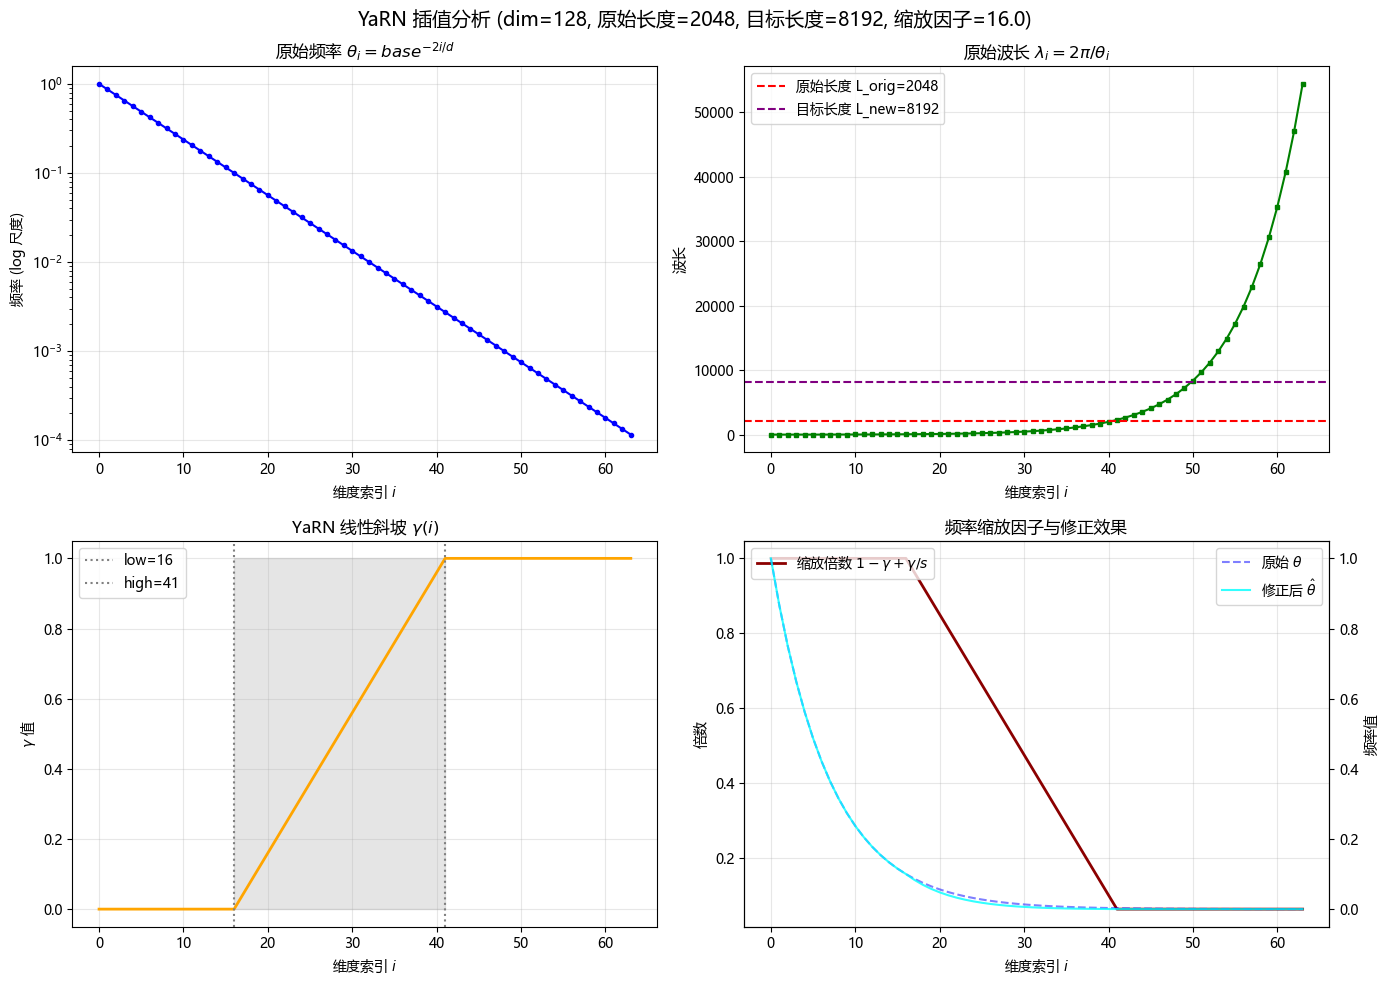

低频插值起始索引 (low)  : 16
高频外推结束索引 (high) : 41
斜坡有效区间宽度        : 26


In [2]:
# ---------- 参数配置 ----------
dim = 128          # head_dim，必须为偶数
rope_base = 10000.0
orig_max = 2048    # 原始预训练长度
end = 8192         # 目标扩展长度（大于 orig_max 才会触发插值）
factor = 16.0      # 缩放因子 s
beta_fast = 32.0
beta_slow = 1.0

# ---------- 1. 计算基础频率 ----------
# i 的取值范围：0 到 dim//2 - 1
i_indices = torch.arange(0, dim // 2)
theta_i = 1.0 / (rope_base ** (2 * i_indices.float() / dim))  # 等价于 base^(-2i/d)

# ---------- 2. 计算 YaRN 线性斜坡 gamma(i) ----------
# 定义 inv_dim 函数
def inv_dim(b):
    # 注意：这里的 log 是自然对数，与代码中 math.log 一致
    return (dim * math.log(orig_max / (b * 2 * math.pi))) / (2 * math.log(rope_base))

low = max(math.floor(inv_dim(beta_fast)), 0)
high = min(math.ceil(inv_dim(beta_slow)), dim // 2 - 1)

# 计算 ramp (gamma)
ramp = torch.clamp((i_indices.float() - low) / max(high - low, 0.001), 0, 1)

# ---------- 3. 计算缩放后的频率 ----------
# 如果 end / orig_max <= 1.0，则 gamma 全为0，此处我们强制激活以展示效果
scale_factor = 1 - ramp + ramp / factor
theta_scaled = theta_i * scale_factor

# ---------- 4. 计算波长 ----------
wavelength_orig = 2 * math.pi / (theta_i + 1e-9)  # 加极小值防止除零
wavelength_scaled = 2 * math.pi / (theta_scaled + 1e-9)

# ---------- 5. 绘图 ----------
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'YaRN 插值分析 (dim={dim}, 原始长度={orig_max}, 目标长度={end}, 缩放因子={factor})', fontsize=14)

# 子图 1: 原始频率 (对数坐标)
axs[0, 0].plot(i_indices.numpy(), theta_i.numpy(), color='blue', marker='o', markersize=3)
axs[0, 0].set_yscale('log')
axs[0, 0].set_title('原始频率 $\\theta_i = base^{-2i/d}$')
axs[0, 0].set_xlabel('维度索引 $i$')
axs[0, 0].set_ylabel('频率 (log 尺度)')
axs[0, 0].grid(True, alpha=0.3)

# 子图 2: 原始波长 (线性坐标)
axs[0, 1].plot(i_indices.numpy(), wavelength_orig.numpy(), color='green', marker='s', markersize=3)
axs[0, 1].axhline(y=orig_max, color='red', linestyle='--', label=f'原始长度 L_orig={orig_max}')
axs[0, 1].axhline(y=end, color='purple', linestyle='--', label=f'目标长度 L_new={end}')
axs[0, 1].set_title('原始波长 $\\lambda_i = 2\\pi / \\theta_i$')
axs[0, 1].set_xlabel('维度索引 $i$')
axs[0, 1].set_ylabel('波长')
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# 子图 3: YaRN 斜坡 gamma(i)
axs[1, 0].plot(i_indices.numpy(), ramp.numpy(), color='orange', linewidth=2)
axs[1, 0].axvline(x=low, color='gray', linestyle=':', label=f'low={low}')
axs[1, 0].axvline(x=high, color='gray', linestyle=':', label=f'high={high}')
axs[1, 0].fill_between(i_indices.numpy(), 0, 1, where=(i_indices >= low) & (i_indices <= high), alpha=0.2, color='gray')
axs[1, 0].set_title('YaRN 线性斜坡 $\\gamma(i)$')
axs[1, 0].set_xlabel('维度索引 $i$')
axs[1, 0].set_ylabel('$\\gamma$ 值')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# 子图 4: 缩放倍数以及修正后的频率对比
axs[1, 1].plot(i_indices.numpy(), scale_factor.numpy(), color='darkred', linewidth=2, label='缩放倍数 $1-\\gamma+\\gamma/s$')
axs[1, 1].set_title('频率缩放因子与修正效果')
axs[1, 1].set_xlabel('维度索引 $i$')
axs[1, 1].set_ylabel('倍数')
axs[1, 1].legend(loc='upper left')
axs[1, 1].grid(True, alpha=0.3)

# 在子图4上叠加修正前后的频率对比（双纵轴）
ax2 = axs[1, 1].twinx()
ax2.plot(i_indices.numpy(), theta_i.numpy(), color='blue', alpha=0.5, linestyle='--', label='原始 $\\theta$')
ax2.plot(i_indices.numpy(), theta_scaled.numpy(), color='cyan', alpha=0.8, linestyle='-', label='修正后 $\\hat{\\theta}$')
ax2.set_ylabel('频率值', color='black')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# 打印关键临界索引
print(f"低频插值起始索引 (low)  : {low}")
print(f"高频外推结束索引 (high) : {high}")
print(f"斜坡有效区间宽度        : {high - low + 1}")